# Phylogenetic Analysis of WS/DGAT Homologs Assigned to Actinomycetota (OR07 Metagenomic Library)

**Author:** Virginia Galván, PhD  
**Associated publication:** Galván et al. (2023) *PLOS ONE* — https://doi.org/10.1371/journal.pone.0288509  
**Associated thesis:** Galván V. (2026). *Functional characterization of WS/DGAT enzymes from taxonomically diverse uncultured marine microorganisms* — Chapter I, Sections 6.6 and 7.3.5

---

## Biological context

Notebook 02 showed that Actinomycetota (Terrabacteria) is the second most abundant lineage carrying WS/DGAT biosynthetic potential, and a particularly large contributor in the OR07 intertidal library. Taxonomic assignment alone, however, doesn't say how these putative enzymes relate to each other or to previously characterized WS/DGATs — whether they are close relatives of known, well-studied enzymes (useful for functional inference by homology) or divergent sequences that might represent genuinely novel biochemistry (useful as prospecting candidates). A phylogenetic tree answers that question directly.

## Methods summary

The 85 OR07 metagenomic sequences assigned to Actinomycetota were combined with every PF03007-containing sequence from Actinomycetota genomes in IMG/M (12,123 sequences after 100%-identity dereplication with CD-HIT), the top Blastp hit (nr) per metagenomic query, and a curated set of characterized reference WS/DGAT enzymes. A first Neighbor-Joining attempt across this full set failed (too few conserved, non-gapped alignment columns across >12,000 divergent sequences), so the set was narrowed to genomic/reference sequences sharing ≥65% identity with the OR07 queries — a threshold chosen empirically to balance alignment quality against how many OR07 sequences still had a genomic match. Ambiguous gene starts were corrected using RAST and ORFfinder against the original MetaGeneMark calls, and the alignment was refined iteratively (removing overly divergent unclustered sequences and near-identical genomic redundancy). The final dataset — **125 sequences: 59 OR07 metagenomic + 66 database-derived** — was used to build a Maximum-Likelihood tree (100 bootstrap replicates) in **MEGA-X**, rooted with a Gammaproteobacteria outgroup.

Tree construction (alignment, model selection, ML inference) was done in MEGA-X, as described above; this notebook loads the resulting tree and does everything downstream in Python — classifying every sequence by origin, testing whether OR07 paralogs cluster together or are dispersed, computing nearest-neighbor patristic distances, and checking whether bootstrap support differs across the tree.

```
PF03007 hits: OR07 metagenomic (85) + IMG genomic (12,123 × 100%-dereplicated) + Blastp top hits + reference enzymes
        │
        ▼
  65%-identity clustering → select genomic/reference sequences closest to OR07 queries
        │
        ▼
  MSA → Maximum-Likelihood tree (MEGA-X, 100 bootstrap reps, Gammaproteobacteria outgroup)
        │
        ▼
  125-sequence tree (.nwk) → loaded and analyzed here (Python, this notebook)
```

**Input file:**
- `data/Actinob_Tree_curated.nwk` — the final 125-sequence Maximum-Likelihood tree, with sequence names as deposited/annotated in their source database (IMG, NCBI) or, for OR07, the original metagenomic gene ID.

## 0. Setup

In [1]:
import re
import itertools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

!pip install biopython

from Bio import Phylo

DATA_DIR = '../data' if __import__('os').path.exists('../data') else '.'

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 9,
    'figure.dpi': 150
})

CATEGORY_COLORS = {
    'OR07 metagenomic': '#C0392B',
    'Blastp hit (database)': '#2E86AB',
    'IMG genomic (database)': '#27AE60',
    'Reference / characterized (database)': '#7D6608',
    'Outgroup (Gammaproteobacteria)': '#999999',
}

print('Setup complete')

Defaulting to user installation because normal site-packages is not writeable


Setup complete


## 1. Load tree

A quick orientation on the three numbers below: **leaves** are the 125 sequences themselves (the tips of the tree). **Internal nodes** are the branch points, each representing an inferred common ancestor of the sequences descending from it — with 125 leaves, a fully bifurcating tree would have 124 of these, but this one has 123, because the root splits into 3 lineages instead of 2 (a common, unremarkable feature of ML trees). **Bootstrap support** is a confidence value (0–100%, from the 100 resampling replicates used to build the tree) attached to each internal node except the root — the root isn't itself a testable grouping, so it doesn't get one.

In [2]:
tree = Phylo.read(f'{DATA_DIR}/Actinob_Tree_curated.nwk', 'newick')
terminals = tree.get_terminals()
internals = tree.get_nonterminals()

print(f'Leaves (sequences): {len(terminals)}')
print(f'Internal nodes: {len(internals)}')
print(f'Internal nodes with bootstrap support: {sum(1 for c in internals if c.confidence is not None)}')

Leaves (sequences): 125
Internal nodes: 123
Internal nodes with bootstrap support: 122


## 2. Classify sequences by origin

Every sequence in the tree falls into one of five categories:

| Origin | Description |
|---|---|
| OR07 metagenomic | Sequence identified in the OR07 intertidal metagenomic library |
| Blastp hit (database) | Top Blastp hit (nr) for an OR07 query |
| IMG genomic (database) | Hit from an Actinomycetota genome in IMG/M |
| Reference / characterized (database) | Previously characterized WS/DGAT enzyme (curated set) |
| Outgroup (Gammaproteobacteria) | Used to root the tree |

Two naming details worth knowing when reading OR07 sequence IDs: a leading **`P_`** marks a **partial sequence** (doesn't cover the full predicted gene length), and a **`_Nt`** / **`_Ct`** suffix marks a sequence that was **split in two** — one metagenomic gene had two copies of the PF03007 domain, so it was separated into its N-terminal and C-terminal halves for the alignment.

In [3]:
ORIGIN_NAMES = {
    'OR07': 'OR07 metagenomic',
    'BLASTP': 'Blastp hit (database)',
    'IMG': 'IMG genomic (database)',
    'REF': 'Reference / characterized (database)',
    'OUTGROUP': 'Outgroup (Gammaproteobacteria)',
}

def classify(name):
    tag = name.split('__', 1)[0]
    return ORIGIN_NAMES[tag]

def display_label(name):
    """Strip the ORIGIN__ tag for anything meant to be read by a person (figure, tables)."""
    return name.split('__', 1)[1]

origin = {t.name: classify(t.name) for t in terminals}
counts = pd.Series(origin.values()).value_counts()
print(counts)
print()
n_or07 = counts.get('OR07 metagenomic', 0)
n_db = sum(v for k, v in counts.items() if k != 'OR07 metagenomic')
print(f'OR07 metagenomic: {n_or07}  |  Database-derived (incl. outgroup): {n_db}  |  Total: {n_or07 + n_db}')

OR07 metagenomic                        59
Blastp hit (database)                   24
IMG genomic (database)                  22
Reference / characterized (database)    18
Outgroup (Gammaproteobacteria)           2
Name: count, dtype: int64

OR07 metagenomic: 59  |  Database-derived (incl. outgroup): 66  |  Total: 125


## 3. Figure 1 — Maximum-Likelihood tree

Tips are colored by sequence origin; branch labels show bootstrap support ≥ 70% (values below that are omitted to keep the tree legible).

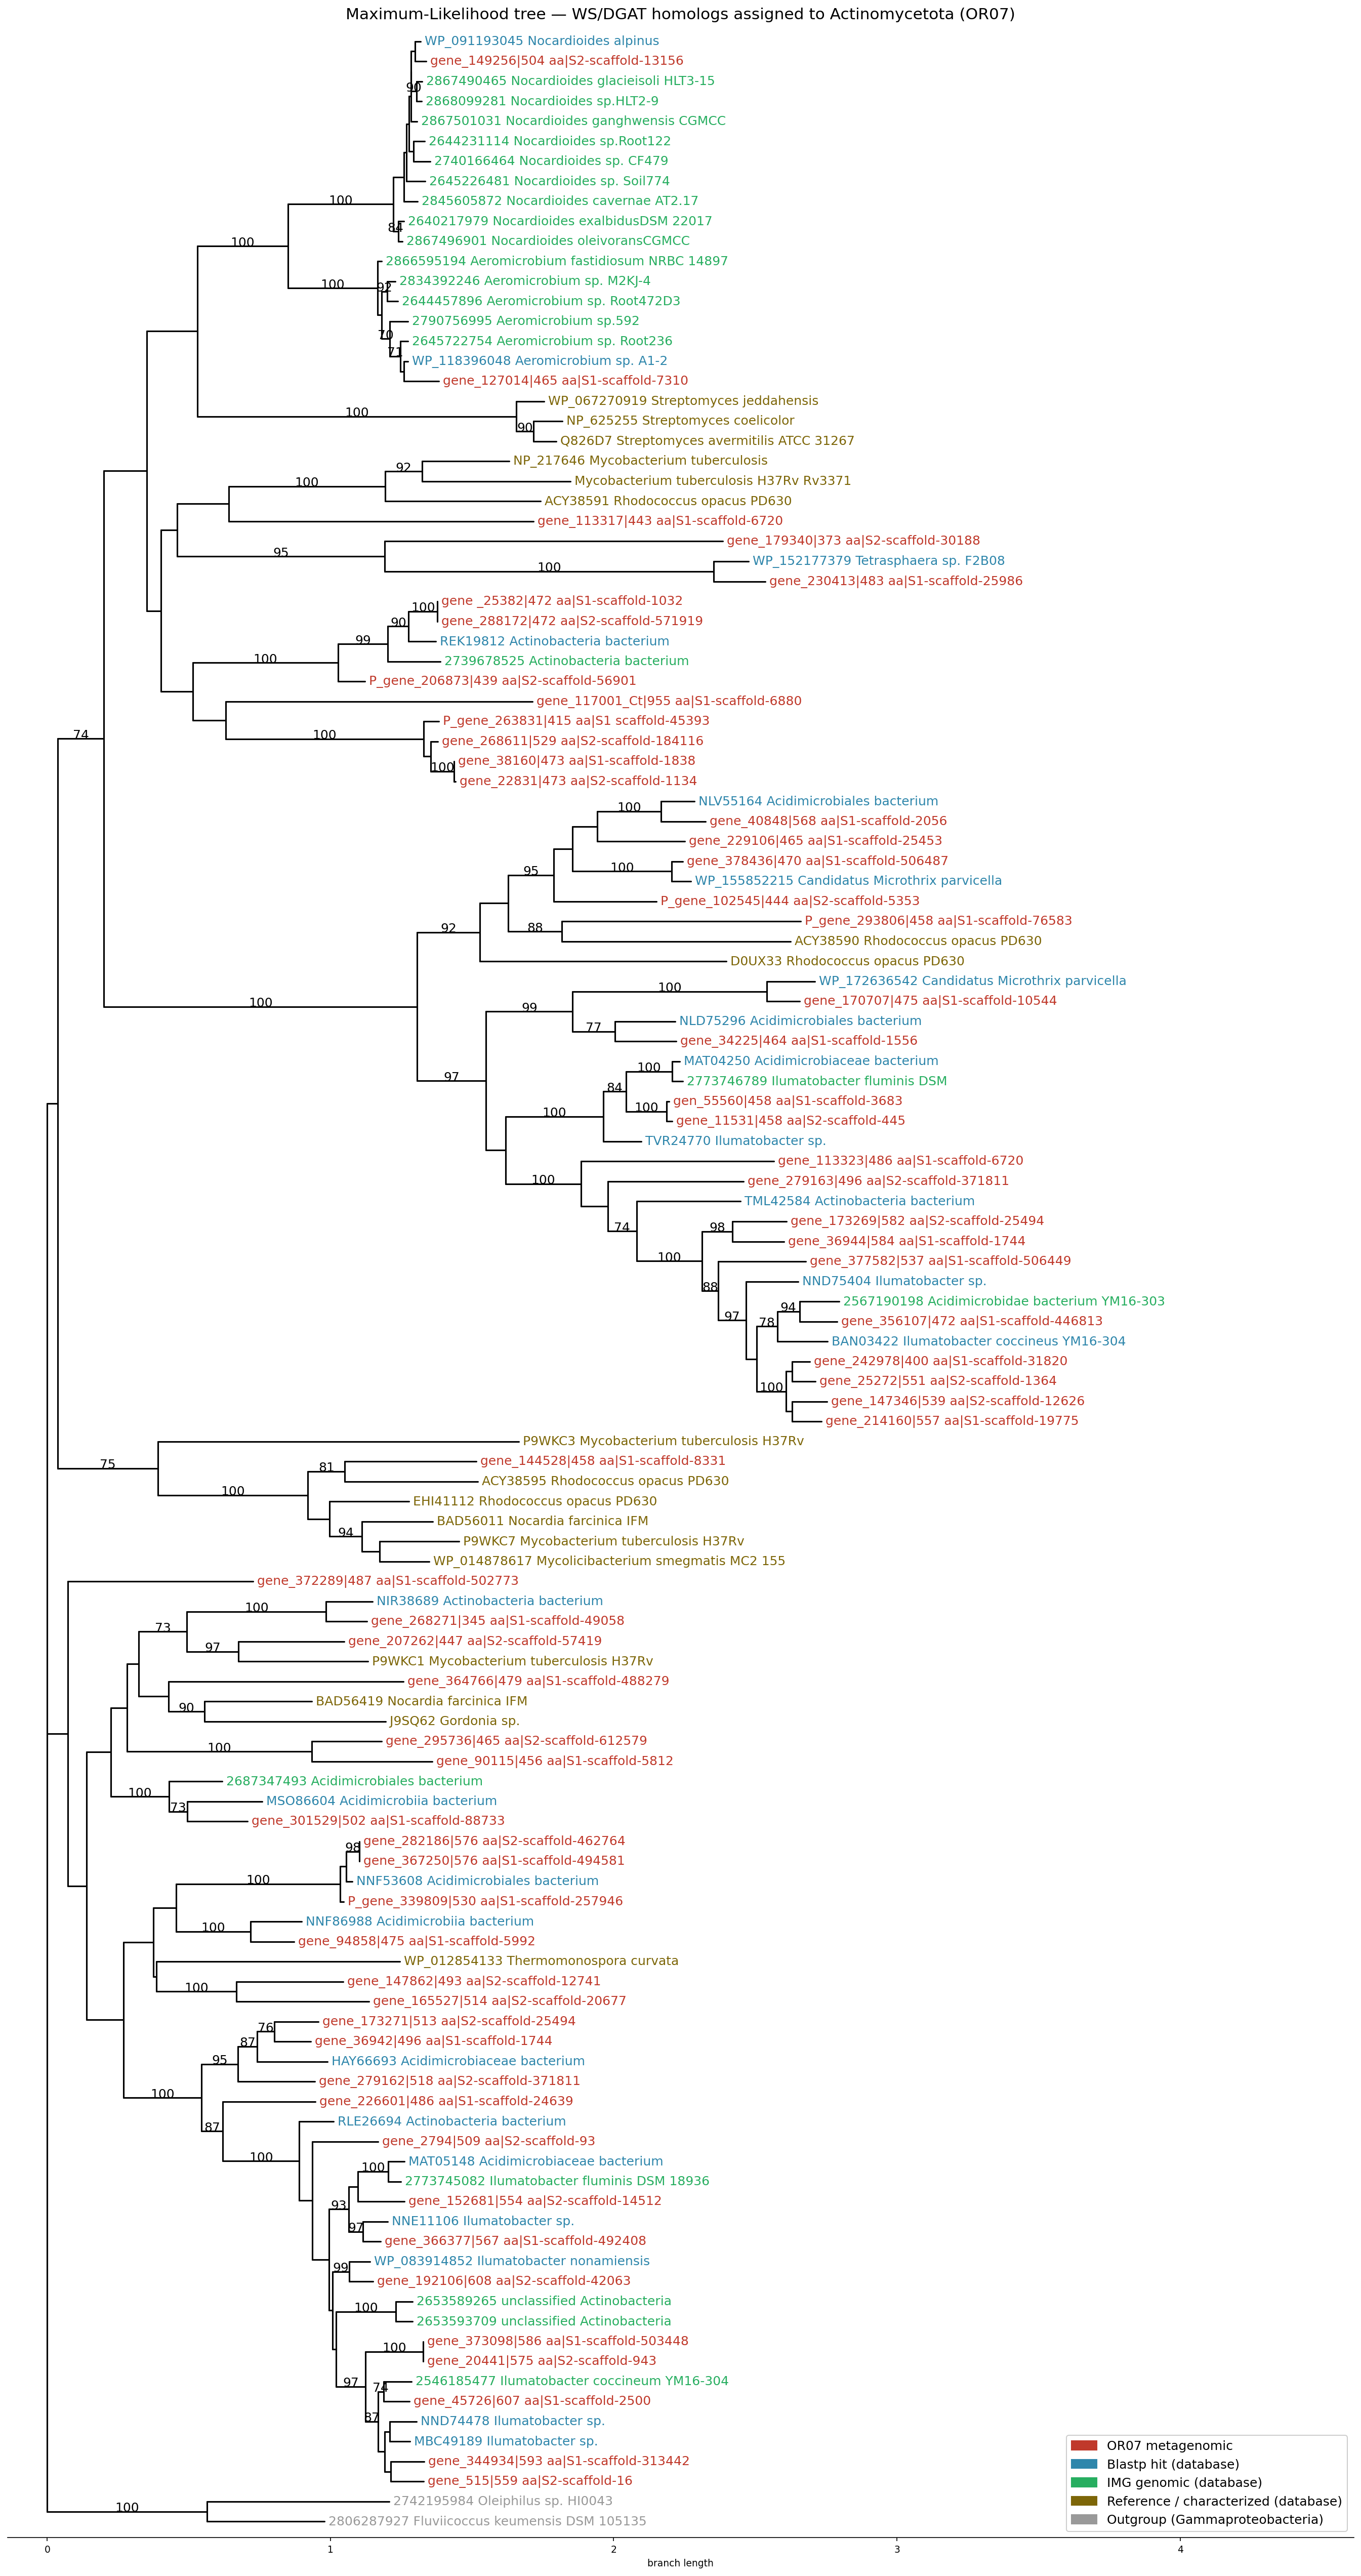

In [4]:
label_func = lambda c: display_label(c.name) if c.is_terminal() else None
label_colors = {display_label(t.name): CATEGORY_COLORS[classify(t.name)] for t in terminals}
branch_labels = lambda c: (f"{int(round(c.confidence * 100))}" if (c.confidence is not None and c.confidence >= 0.7) else '')

fig = plt.figure(figsize=(18, 34))
ax = fig.add_subplot(1, 1, 1)
Phylo.draw(tree, axes=ax, do_show=False,
           label_func=label_func,
           label_colors=label_colors,
           branch_labels=branch_labels)

# Bigger, more legible tip/branch labels than the matplotlib default.
for t in ax.texts:
    t.set_fontsize(12)

# The y-axis has no meaning here (leaf vertical position is just spacing, not
# a plotted quantity), so it's removed. A modest amount of right-hand room is
# added so long tip labels have space to sit in without excess blank canvas,
# and the box around the plot is dropped so labels are free to extend into
# empty space instead of appearing to spill past a border.
ax.set_ylabel('')
ax.set_yticks([])
xmin, xmax = ax.get_xlim()
ax.set_xlim(xmin, xmax * 1.32)
for side in ('top', 'right', 'left'):
    ax.spines[side].set_visible(False)

legend_handles = [mpatches.Patch(color=c, label=k) for k, c in CATEGORY_COLORS.items()]
ax.legend(handles=legend_handles, loc='lower right', fontsize=12, framealpha=0.95)
ax.set_title('Maximum-Likelihood tree — WS/DGAT homologs assigned to Actinomycetota (OR07)', fontsize=15)

plt.tight_layout()
plt.savefig('fig1_actinomycetota_tree.png', dpi=200, bbox_inches='tight')
plt.show()

## 4. Composition summary

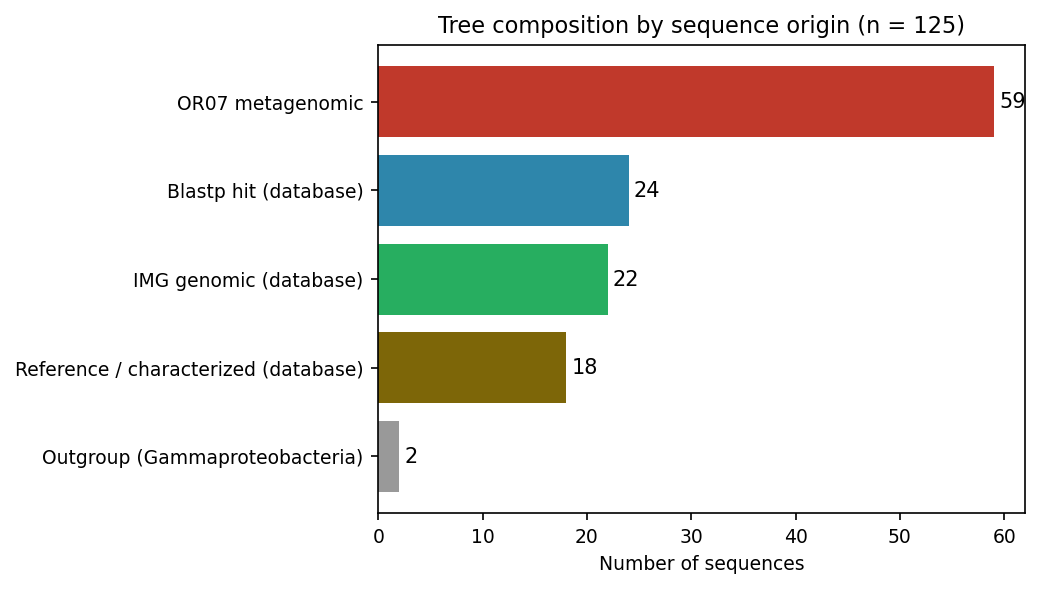

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
order = counts.index.tolist()
ax.barh(order, counts.values, color=[CATEGORY_COLORS[c] for c in order])
for i, v in enumerate(counts.values):
    ax.text(v + 0.5, i, str(v), va='center', fontsize=10)
ax.set_xlabel('Number of sequences')
ax.set_title('Tree composition by sequence origin (n = 125)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('fig2_composition_summary.png', dpi=200, bbox_inches='tight')
plt.show()

## 5. Are OR07 paralogs clustered or dispersed across the tree?

Every internal node is checked for whether **all** of its descendant leaves are OR07 sequences. Maximal such nodes (not nested inside a larger all-OR07 clade) identify groups of OR07 paralogs that are each other's closest relatives in the tree, as opposed to OR07 sequences whose nearest relatives are database sequences.

In [6]:
def all_or07(clade):
    leaves = clade.get_terminals()
    return all(classify(l.name) == 'OR07 metagenomic' for l in leaves)

maximal_or07_clades = []
for c in internals:
    if all_or07(c):
        leaves = frozenset(l.name for l in c.get_terminals())
        if not any(leaves < other for other in maximal_or07_clades):
            maximal_or07_clades = [s for s in maximal_or07_clades if not s < leaves]
            maximal_or07_clades.append(leaves)

cluster_sizes = sorted((len(s) for s in maximal_or07_clades), reverse=True)
n_clustered = sum(cluster_sizes)
n_total_or07 = sum(1 for v in origin.values() if v == 'OR07 metagenomic')
n_isolated = n_total_or07 - n_clustered

print(f'OR07 sequences total: {n_total_or07}')
print(f'OR07-only clusters found (\u2265 2 OR07 sequences as nearest relatives): {len(cluster_sizes)}')
print(f'Cluster sizes: {cluster_sizes}')
print(f'OR07 sequences within an OR07-only cluster: {n_clustered} ({n_clustered/n_total_or07:.0%})')
print(f'OR07 sequences with no OR07 sister (isolated among database sequences): {n_isolated} ({n_isolated/n_total_or07:.0%})')

OR07 sequences total: 59
OR07-only clusters found (≥ 2 OR07 sequences as nearest relatives): 11
Cluster sizes: [5, 4, 2, 2, 2, 2, 2, 2, 2, 2, 2]
OR07 sequences within an OR07-only cluster: 27 (46%)
OR07 sequences with no OR07 sister (isolated among database sequences): 32 (54%)


## 6. Is the tree equally well-supported where OR07 sequences sit?

The dispersion result above says OR07 paralogs are scattered rather than clustered — but that's only a meaningful signal if the tree is reliably resolved in the parts where they sit. This compares bootstrap support for internal nodes that have at least one OR07 descendant against nodes that are exclusively database sequences, using the confidence values already present in the tree file (no additional data needed).

In [7]:
from scipy import stats

with_or07_support = []
without_or07_support = []
for c in internals:
    if c.confidence is None:
        continue
    leaves = c.get_terminals()
    has_or07 = any(classify(l.name) == 'OR07 metagenomic' for l in leaves)
    (with_or07_support if has_or07 else without_or07_support).append(c.confidence * 100)

u_stat, p_val = stats.mannwhitneyu(with_or07_support, without_or07_support, alternative='two-sided')

print(f'Nodes with \u2265 1 OR07 descendant: n={len(with_or07_support)}, mean bootstrap support = {sum(with_or07_support)/len(with_or07_support):.1f}%')
print(f'Nodes with database sequences only: n={len(without_or07_support)}, mean bootstrap support = {sum(without_or07_support)/len(without_or07_support):.1f}%')
print(f'Mann-Whitney U p-value = {p_val:.4f}')

Nodes with ≥ 1 OR07 descendant: n=105, mean bootstrap support = 71.5%
Nodes with database sequences only: n=17, mean bootstrap support = 84.3%
Mann-Whitney U p-value = 0.1443


## 7. Nearest database relative of each OR07 sequence

For each OR07 sequence, the database sequence with the smallest patristic (tree) distance is identified — i.e. its closest known relative in this tree. This is useful for prioritizing candidates: an OR07 sequence whose nearest relative is a *characterized* enzyme can be functionally inferred by homology, while one far from anything characterized is a better candidate for novel-activity prospecting.

In [8]:
or07_leaves = [t for t in terminals if classify(t.name) == 'OR07 metagenomic']
db_leaves = [t for t in terminals if classify(t.name) not in ('OR07 metagenomic', 'Outgroup (Gammaproteobacteria)')]

rows = []
for o in or07_leaves:
    dists = sorted(((tree.distance(o, d), d) for d in db_leaves), key=lambda x: x[0])
    nearest_dist, nearest = dists[0]
    rows.append({
        'OR07 sequence': display_label(o.name).split('|')[0].lstrip('P_'),
        'Nearest DB relative': display_label(nearest.name),
        'Nearest DB category': classify(nearest.name),
        'Patristic distance': round(nearest_dist, 4),
    })
nn_df = pd.DataFrame(rows).sort_values('Patristic distance').reset_index(drop=True)

print('Nearest-relative category distribution:')
print(nn_df['Nearest DB category'].value_counts())
print()
print('10 closest OR07-to-database pairs in the whole tree:')
nn_df.head(10)

Nearest-relative category distribution:
Nearest DB category
Blastp hit (database)                   47
IMG genomic (database)                   7
Reference / characterized (database)     5
Name: count, dtype: int64

10 closest OR07-to-database pairs in the whole tree:


,OR07 sequence,Nearest DB relative,Nearest DB category,Patristic distance
0,gene_339809,NNF53608 Acidimicrobiales bacterium,Blastp hit (database),0.0536
1,gene_149256,WP_091193045 Nocardioides alpinus,Blastp hit (database),0.0586
2,gene_282186,NNF53608 Acidimicrobiales bacterium,Blastp hit (database),0.0677
3,gene_367250,NNF53608 Acidimicrobiales bacterium,Blastp hit (database),0.0677
4,gene_378436,WP_155852215 Candidatus Microthrix parvicella,Blastp hit (database),0.1082
5,gene_127014,WP_118396048 Aeromicrobium sp. A1-2,Blastp hit (database),0.1380
6,gene_366377,NNE11106 Ilumatobacter sp.,Blastp hit (database),0.1491
7,gene_192106,WP_083914852 Ilumatobacter nonamiensis,Blastp hit (database),0.1572
8,gene_45726,2546185477 Ilumatobacter coccineum YM16-304,IMG genomic (database),0.1890
9,gene_288172,REK19812 Actinobacteria bacterium,Blastp hit (database),0.1980


### 7.1 Genera of interest: *Ilumatobacter* and *Candidatus* Microthrix

These two genera were independently flagged by scaffold-level taxonomic assignment (Galván, PhD Thesis — a separate method from this tree) as closely related to OR07's Actinomycetota community. Here, the nearest-neighbor table above is filtered for OR07 sequences whose closest relative in the tree belongs to either genus — an independent, tree-based check of that association.

In [9]:
for genus in ['Ilumatobacter', 'Microthrix']:
    sub = nn_df[nn_df['Nearest DB relative'].str.contains(genus, case=False)]
    print(f'{genus}: nearest relative for {len(sub)} OR07 sequences (of {len(or07_leaves)} total)')

print()
nn_df[nn_df['Nearest DB relative'].str.contains('Ilumatobacter|Microthrix', case=False)]

Ilumatobacter: nearest relative for 15 OR07 sequences (of 59 total)
Microthrix: nearest relative for 3 OR07 sequences (of 59 total)



,OR07 sequence,Nearest DB relative,Nearest DB category,Patristic distance
4,gene_378436,WP_155852215 Candidatus Microthrix parvicella,Blastp hit (database),0.1082
6,gene_366377,NNE11106 Ilumatobacter sp.,Blastp hit (database),0.1491
7,gene_192106,WP_083914852 Ilumatobacter nonamiensis,Blastp hit (database),0.1572
8,gene_45726,2546185477 Ilumatobacter coccineum YM16-304,IMG genomic (database),0.1890
11,gene_515,MBC49189 Ilumatobacter sp.,Blastp hit (database),0.2271
12,gene_344934,MBC49189 Ilumatobacter sp.,Blastp hit (database),0.2287
15,gene_170707,WP_172636542 Candidatus Microthrix parvicella,Blastp hit (database),0.2851
18,gene_152681,2773745082 Ilumatobacter fluminis DSM 18936,IMG genomic (database),0.3148
22,gene_20441,MBC49189 Ilumatobacter sp.,Blastp hit (database),0.3621
23,gene_373098,MBC49189 Ilumatobacter sp.,Blastp hit (database),0.3621


## 8. Summary table

In [10]:
nn_df.to_csv('or07_nearest_relatives.csv', index=False)
print('Exported: or07_nearest_relatives.csv')
nn_df

Exported: or07_nearest_relatives.csv


,OR07 sequence,Nearest DB relative,Nearest DB category,Patristic distance
0,gene_339809,NNF53608 Acidimicrobiales bacterium,Blastp hit (database),0.0536
1,gene_149256,WP_091193045 Nocardioides alpinus,Blastp hit (database),0.0586
2,gene_282186,NNF53608 Acidimicrobiales bacterium,Blastp hit (database),0.0677
3,gene_367250,NNF53608 Acidimicrobiales bacterium,Blastp hit (database),0.0677
4,gene_378436,WP_155852215 Candidatus Microthrix parvicella,Blastp hit (database),0.1082
5,gene_127014,WP_118396048 Aeromicrobium sp. A1-2,Blastp hit (database),0.1380
6,gene_366377,NNE11106 Ilumatobacter sp.,Blastp hit (database),0.1491
7,gene_192106,WP_083914852 Ilumatobacter nonamiensis,Blastp hit (database),0.1572
8,gene_45726,2546185477 Ilumatobacter coccineum YM16-304,IMG genomic (database),0.1890
9,gene_288172,REK19812 Actinobacteria bacterium,Blastp hit (database),0.1980


## 9. Key findings

1. **The final tree spans 125 sequences**: 59 from the OR07 metagenomic library and 66 database-derived (24 Blastp hits, 22 IMG genomic hits, 18 characterized reference enzymes, 2 Gammaproteobacteria outgroup), recovered directly from sequence-name patterns in the Newick file.

2. **OR07 paralogs are mostly dispersed, not clustered**: only 27 of 59 OR07 sequences (46%) fall into an OR07-only sub-clade (11 such clusters, sizes 2–5); the remaining 32 (54%) have no OR07 sister sequence at all — their closest relative in the tree is always a database sequence. This is consistent with multiple, independent acquisitions/duplications of WS/DGAT-like sequences across the community rather than one large in-library expansion.

3. **That dispersion isn't an artifact of poor tree resolution**: nodes containing at least one OR07 sequence have, on average, slightly lower bootstrap support than database-only nodes (71.5% vs 84.3%), but the difference is not statistically significant (Mann-Whitney p = 0.14). The tree is comparably well-resolved whether or not OR07 sequences sit in a given clade, so the dispersed placement of OR07 paralogs reflects real topology rather than noisy, poorly-supported branching.

4. **Blast top-hit and tree-nearest-neighbor mostly agree, but not always**: the single Blastp hit chosen per OR07 query is also that sequence's nearest neighbor in the full ML tree for 47 of 59 sequences (80%); the rest (12 sequences) have a different, often genomic, sequence as their true closest tree relative — a reminder that BLAST identity ranking and multiple-sequence-alignment-based phylogeny don't always agree, and that the tree adds information beyond a single best-hit search.

5. ***Ilumatobacter* and *Candidatus* Microthrix are recurrent nearest relatives**: independently of any taxonomic assignment of the host scaffolds, the tree itself places 15 OR07 sequences closest to *Ilumatobacter* references and 3 closest to *Candidatus* Microthrix — the same two genera flagged from scaffold-level taxonomy, now corroborated from sequence relatedness alone.

---

## References

- Galván V. et al. (2023). High potential for the biosynthesis of neutral lipid storage compounds in chronically-polluted subantarctic sediments. *PLOS ONE*, 18(7). https://doi.org/10.1371/journal.pone.0288509
- Galván V. (2026). Functional characterization of WS/DGAT enzymes from taxonomically diverse uncultured marine microorganisms. PhD Thesis, Chapter I, Sections 6.6 and 7.3.5.
- Villa J.A. et al. (2014). Diversity and evolution of diacylglycerol acyltransferases (DGATs) in actinobacteria. *Applied Microbiology and Biotechnology*.
- Kumar S. et al. (2018). MEGA X: Molecular Evolutionary Genetics Analysis across computing platforms. *Molecular Biology and Evolution*, 35(6), 1547-1549.
- Cock P.J.A. et al. (2009). Biopython: freely available Python tools for computational molecular biology and bioinformatics. *Bioinformatics*, 25(11), 1422-1423.